In [74]:
import pandas as pd
import numpy as np

In [75]:
file = r'cryptos.csv'
data = pd.read_csv(file, index_col="Date", parse_dates=True)

In [76]:
log_returns = np.log(data / data.shift(1))

In [77]:
log_returns.dropna(inplace=True)

# **ESTACIONARIOS**

In [78]:
from statsmodels.tsa.stattools import adfuller

In [79]:
def adf_test(series, name=''):
    result = adfuller(series)
    if result[1] <= 0.05:
        print(f"{name} es estacionaria, pvalue = {result[1]}")
    else:
        print(f"{name} no es estacionaria, pvalue = {result[1]}")
    return result[1]

In [80]:
pvalores = []

for col in log_returns.columns:
    pvalor = adf_test(log_returns[col], col)
    if pvalor > 0.05:
        pvalores.append(col, pvalor)


BTC es estacionaria, pvalue = 0.0
ETH es estacionaria, pvalue = 0.0
BNB es estacionaria, pvalue = 0.0
XRP es estacionaria, pvalue = 0.0
ADA es estacionaria, pvalue = 4.603162089772542e-21
SOL es estacionaria, pvalue = 0.0
DOGE es estacionaria, pvalue = 5.492612656860892e-15
TRX es estacionaria, pvalue = 1.146147970443606e-27
TON es estacionaria, pvalue = 1.3895626508394174e-12
MATIC es estacionaria, pvalue = 0.0
DOT es estacionaria, pvalue = 3.143147872541605e-15
LTC es estacionaria, pvalue = 0.0
AVAX es estacionaria, pvalue = 5.375112082639333e-20
DAI es estacionaria, pvalue = 1.538627988833846e-22
LINK es estacionaria, pvalue = 0.0
LEO es estacionaria, pvalue = 6.0357093640423696e-24
XLM es estacionaria, pvalue = 2.2202837440725725e-15
WSTETH es estacionaria, pvalue = 0.0
HBAR es estacionaria, pvalue = 3.6990695405775634e-29
SHIB es estacionaria, pvalue = 4.2264145658933e-24
BCH es estacionaria, pvalue = 0.0


In [81]:
if len(pvalores) > 0:
    print("Las siguientes series no son estacionarias:")
    for col in pvalores:
        print(col)
else:
    print("Todas las series son estacionarias")

Todas las series son estacionarias


# **CAUSALIDAD**

In [82]:
from statsmodels.tsa.stattools import grangercausalitytests

In [83]:
causalidad = grangercausalitytests(log_returns[['BTC', 'ETH']], maxlag=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5884  , p=0.4432  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.5898  , p=0.4425  , df=1
likelihood ratio test: chi2=0.5897  , p=0.4425  , df=1
parameter F test:         F=0.5884  , p=0.4432  , df_denom=1250, df_num=1


In [84]:
causalidad[1][0]['ssr_chi2test'][1] # pvalue

np.float64(0.4424828301789564)

## **para todos**

In [85]:
import itertools

In [86]:
pairs = list(itertools.combinations(log_returns.columns, 2))

In [87]:

pvalores = []
for pair in pairs:
    col1, col2 = pair
    result = grangercausalitytests(log_returns[[col1, col2]], maxlag=1)
    pvalor = result[1][0]['ssr_chi2test'][1]
    if pvalor < 0.10:
        pvalores.append((col1, col2, pvalor))


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5884  , p=0.4432  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.5898  , p=0.4425  , df=1
likelihood ratio test: chi2=0.5897  , p=0.4425  , df=1
parameter F test:         F=0.5884  , p=0.4432  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.9779  , p=0.3229  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.9803  , p=0.3221  , df=1
likelihood ratio test: chi2=0.9799  , p=0.3222  , df=1
parameter F test:         F=0.9779  , p=0.3229  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.2779  , p=0.0705  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=3.2858  , p=0.0699  , df=1
likelihood ratio test: chi2=3.2815  , p=0.0701  , df=1
parameter F test:         F=3.2779  , p=0.0705  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.6782  , p=0.

ssr based F test:         F=0.1958  , p=0.6582  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.1963  , p=0.6578  , df=1
likelihood ratio test: chi2=0.1962  , p=0.6578  , df=1
parameter F test:         F=0.1958  , p=0.6582  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0865  , p=0.7687  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.0867  , p=0.7684  , df=1
likelihood ratio test: chi2=0.0867  , p=0.7684  , df=1
parameter F test:         F=0.0865  , p=0.7687  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1012  , p=0.7505  , df_denom=1250, df_num=1
ssr based chi2 test:   chi2=0.1014  , p=0.7501  , df=1
likelihood ratio test: chi2=0.1014  , p=0.7501  , df=1
parameter F test:         F=0.1012  , p=0.7505  , df_denom=1250, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.3431  , p=0.0210  , df_denom=1250, df_num=1
ssr based chi2

In [88]:
if len(pvalores) > 0:
    print("Las siguientes series son causales:")
    for col1, col2, pvalor in pvalores:
        print(f"{col1} -> {col2}, pvalue = {pvalor}")
else:
    print("No hay series causales")

Las siguientes series son causales:
BTC -> XRP, pvalue = 0.06988220586877834
BTC -> SOL, pvalue = 0.07951460637873269
ETH -> XRP, pvalue = 0.020651997748079444
ETH -> WSTETH, pvalue = 0.09572014878217425
BNB -> XRP, pvalue = 0.07308727150735571
BNB -> TRX, pvalue = 0.016107402061193887
XRP -> TRX, pvalue = 0.00047382501203409907
ADA -> TRX, pvalue = 0.09195534033076112
SOL -> TRX, pvalue = 0.027296478867932808
DOGE -> TRX, pvalue = 0.02639126041998707
TRX -> MATIC, pvalue = 0.00039466925691640563
TRX -> DOT, pvalue = 0.0007087744097838961
TRX -> LTC, pvalue = 1.6978856479071704e-06
TRX -> AVAX, pvalue = 0.00014675858745517774
TRX -> LINK, pvalue = 3.624421674592656e-08
TRX -> LEO, pvalue = 0.07256434135920413
TRX -> WSTETH, pvalue = 0.05259440505781817
TRX -> HBAR, pvalue = 4.6528831923748104e-11
TRX -> BCH, pvalue = 0.09360093685699136
MATIC -> DAI, pvalue = 0.08186464433709546
MATIC -> XLM, pvalue = 0.04348721325461568
MATIC -> WSTETH, pvalue = 0.05404574585738168
MATIC -> BCH, pvalu

# **GRAFO**

In [89]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [90]:
G = nx.DiGraph()
for col1, col2, pvalor in pvalores:
    G.add_edge(col1, col2)

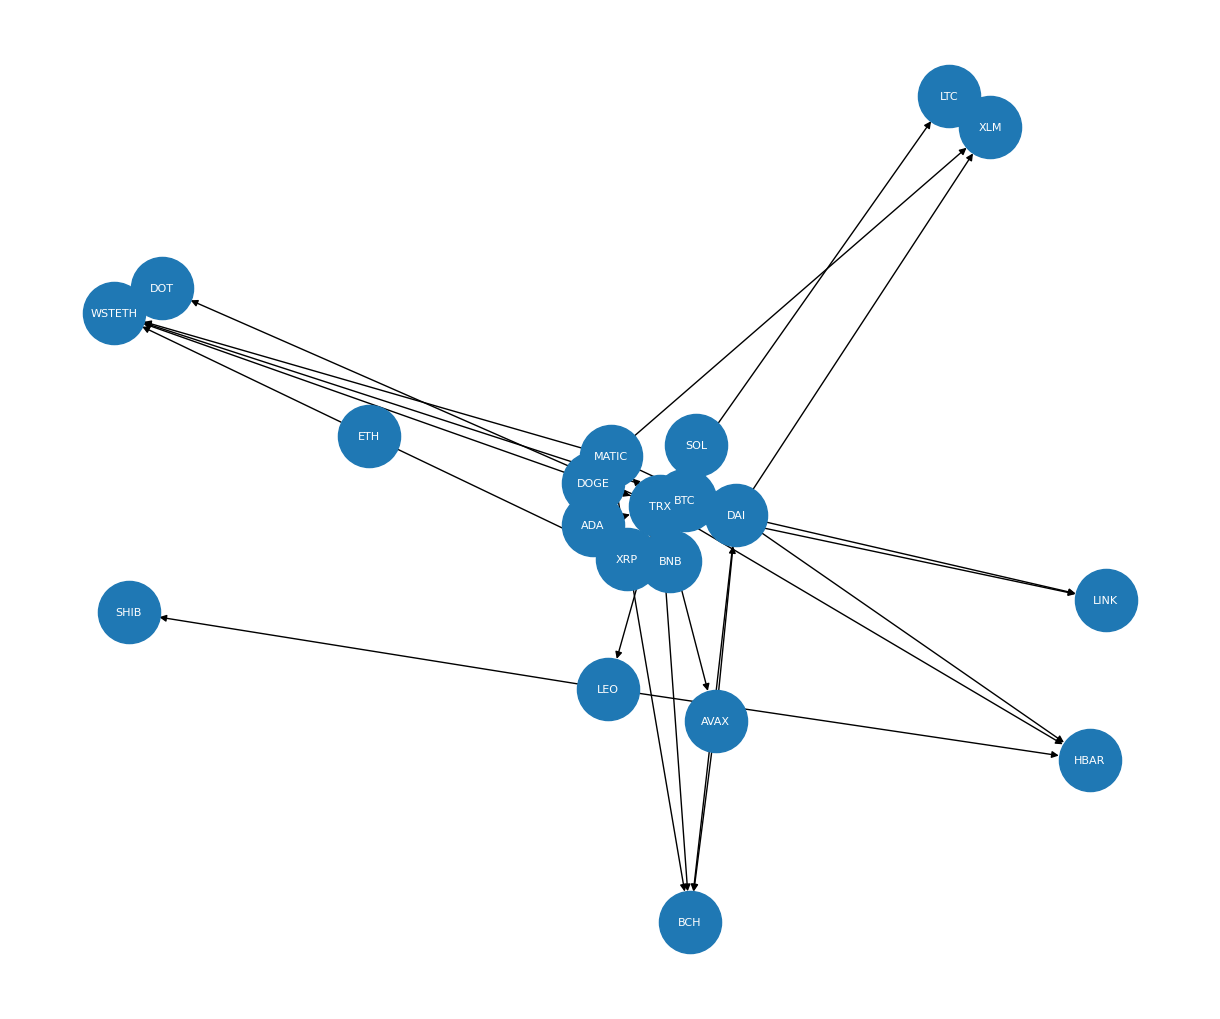

In [96]:
pos = nx.spring_layout(G)
plt.figure(figsize=(12, 10))
nx.draw(G, pos, node_size=2000, font_size=10)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white')
plt.show()